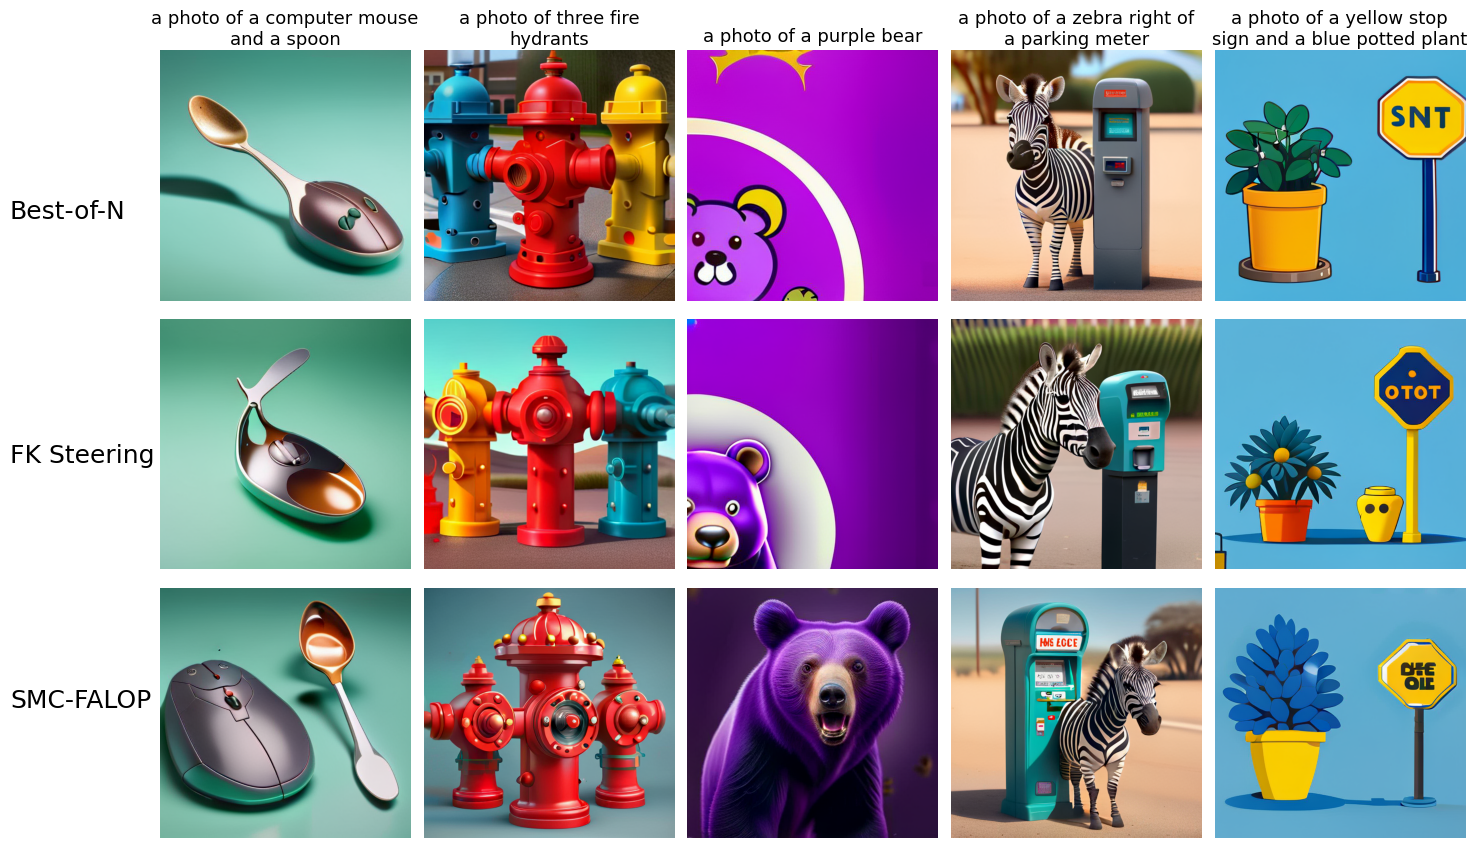

Saved image grid to: smc_meissonic_image_grid.pdf


In [ ]:
"""
create_image_grid.py

Usage:
    - Fill in the three base paths near the bottom of this file (PATH_A, PATH_B, PATH_C).
    - Provide a list of integer indices or zero-padded strings.
    - Run: python create_image_grid.py

This script looks for the file:
    <BASE_PATH>/<index_4_digits>/best_of_n_samples/0000.png
for each of the three base paths and every index in the list, and produces a 3 x N image grid.

Dependencies: Pillow, matplotlib
Install: pip install pillow matplotlib
"""

import os
from typing import List, Sequence, Union, Optional
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import numpy as np
import warnings
import textwrap


def _to_folder_name(idx: Union[int, str]) -> str:
    """Convert an index like 123 or '123' to a zero-padded 5-digit folder name '00123'."""
    try:
        i = int(idx)
    except Exception:
        # if it's not convertible to int, return it as-is (but ensure at least 5 chars)
        s = str(idx)
        return s.zfill(5)
    return f"{i:05d}"


def _make_placeholder(size=(256, 256), text="MISSING") -> Image.Image:
    img = Image.new("RGB", size, (220, 220, 220))
    try:
        draw = ImageDraw.Draw(img)
        # try to use a default font; if not available, skip drawing text
        try:
            font = ImageFont.load_default()
            w, h = draw.textsize(text, font=font)
            draw.text(((size[0]-w)/2, (size[1]-h)/2), text, fill=(80, 80, 80), font=font)
        except Exception:
            pass
    except Exception:
        pass
    return img


def create_image_grid(
    base_paths: Sequence[str],
    indices: Sequence[Union[int, str]],
    out_path: Optional[str] = None,
    show: bool = True,
    placeholder_size=(256, 256),
) -> str:
    """
    Create a 3 x N image grid where rows correspond to the three base_paths and columns to the indices.

    Parameters
    ----------
    base_paths : sequence of 3 strings
        The three directories that each contain folders named 0000, 0001, ...
    indices : sequence of ints or strings
        The indices to include. They will be zero-padded to 4 digits.
    out_path : str or None
        If provided, the resulting figure will be saved to this path. If None, saves to './image_grid.png'.
    show : bool
        If True, calls plt.show() at the end.
    placeholder_size : tuple
        Size used for placeholder images for missing files.

    Returns
    -------
    out_file : str
        Path to the saved image file.
    """
    if len(base_paths) != 3:
        raise ValueError("base_paths must be a sequence of three directory paths.")

    n = len(indices)
    if n == 0:
        raise ValueError("indices list is empty")
    
    prompt_file_path = '/vol/bitbucket/cp524/dev/papers_with_code/Fk-Diffusion-Steering/text_to_image/prompt_files/geneval_metadata.jsonl'
    # Read prompt file
    with open(prompt_file_path, 'r') as f:
        prompt_lines = f.readlines()
    # Parse JSON lines
    import json
    prompts = [json.loads(line) for line in prompt_lines]

    # convert indices to folder names
    folders = [_to_folder_name(idx) for idx in indices]

    # Collect images: rows = 3, cols = n
    images: List[List[Image.Image]] = [[None] * n for _ in range(3)]  # type: ignore

    for r, base in enumerate(base_paths):
        for c, folder in enumerate(folders):
            expected = os.path.join(base, folder, "best_of_n_samples", "00000.png")
            try:
                with Image.open(expected) as im:
                    images[r][c] = im.convert("RGB")
            except FileNotFoundError:
                warnings.warn(f"File not found: {expected}. Using placeholder.")
                images[r][c] = _make_placeholder(size=placeholder_size, text="MISSING")
            except Exception as e:
                warnings.warn(f"Error opening {expected}: {e}. Using placeholder.")
                images[r][c] = _make_placeholder(size=placeholder_size, text="ERROR")

    # Determine a good figsize: base per image cell
    cell_width = 3.0  # inches
    cell_height = 3.0
    fig_w = cell_width * n
    fig_h = cell_height * 3

    fig, axs = plt.subplots(3, n, figsize=(fig_w, fig_h))

    # If n == 1, axs will be shape (3,) not (3,1) — normalize indexing
    if n == 1:
        axs = np.expand_dims(axs, axis=1)
        
    # tweakable parameters
    wrap_width = 28                # characters per line for wrapped column titles
    title_fontsize = 13
    row_title_fontsize = 18
    left_margin = 0.12            # fraction of figure width reserved on left for row titles (increase if row titles clip)
    top_margin = 0.90              # leave space at top for wrapped titles
    
    # default row titles - change as needed
    row_titles = ["Best-of-N", "FK Steering", "SMC-FALOP"]
    
    for r in range(3):
        for c in range(n):
            ax = axs[r, c]
            img = images[r][c]
            ax.imshow(np.asarray(img))
            ax.axis("off")

            # put top-row column labels with the index number + prompt text (wrapped)
            if r == 0:
                # Safe access for prompts: supports prompts being None, dict[index] -> str, or dict[index] -> {'prompt': str}
                prompt_text = prompts[indices[c]]['prompt'] # type: ignore
                # full_title = f"{folders[c]}" + f" — {prompt_text}"
                full_title = prompt_text
                wrapped = textwrap.fill(full_title, width=wrap_width)
                ax.set_title(wrapped, fontsize=title_fontsize)
                ax.title.set_wrap(True)

    # Add row titles on the left, vertically centered next to each row.
    # We compute each row's vertical center using the axes position bbox so placement is accurate.
    for r in range(3):
        # anchor x slightly inside left margin; use figure coordinates
        x_text = 0.02  # small offset inside the very-left; subplots_adjust(left=...) already reserved space
        # use the first axes in the row to compute the vertical center
        ax0 = axs[r, 0]
        bbox = ax0.get_position()  # Bbox in figure coordinates
        y_center = bbox.y0 + bbox.height / 2.0 - 0.05
        # print(y_center)
        fig.text(x_text, y_center, row_titles[r], ha="left", va="center", fontsize=row_title_fontsize)

    
    plt.tight_layout()
    # adjust margins to make room for row titles and wrapped column titles
    plt.subplots_adjust(left=left_margin, top=top_margin)

    if out_path is None:
        out_path = os.path.abspath("image_grid.png")

    plt.savefig(out_path, bbox_inches="tight", format=out_path.split('.')[-1].lower())

    if show:
        plt.show()

    plt.close(fig)
    return out_path


best_of_n_results_file_path = '/vol/bitbucket/cp524/dev/papers_with_code/Fk-Diffusion-Steering/text_to_image/geneval_metadata_results_best/20250712-101225/results.jsonl'
fk_steering_results_file_path = '/vol/bitbucket/cp524/dev/papers_with_code/Fk-Diffusion-Steering/text_to_image/geneval_metadata_results_best/20250824-204601/results.jsonl'
falop_results_file_path = '/vol/bitbucket/cp524/dev/SMC_Meissonic_2/geneval_metadata_results_best/20250813-103626/results.jsonl'

if __name__ == "__main__":
    # === EDIT THESE THREE PATHS BEFORE RUNNING ===
    PATH_BEST_OF_N = "/vol/bitbucket/cp524/dev/papers_with_code/Fk-Diffusion-Steering/text_to_image/geneval_metadata_outputs/20250712-101225"      # <-- fill me
    PATH_FK_STEERKING = "/vol/bitbucket/cp524/dev/papers_with_code/Fk-Diffusion-Steering/text_to_image/geneval_metadata_outputs/20250824-204601"  # <-- fill me
    PATH_FALOP = "/vol/bitbucket/cp524/dev/SMC_Meissonic_2/geneval_metadata_outputs/20250813-103626"             # <-- fill me
    
    # PATH_BEST_OF_N = "/vol/bitbucket/cp524/dev/papers_with_code/Fk-Diffusion-Steering/text_to_image/geneval_metadata_outputs/20250712-220301"      # <-- fill me
    # PATH_FK_STEERKING = "/vol/bitbucket/cp524/dev/papers_with_code/Fk-Diffusion-Steering/text_to_image/geneval_metadata_outputs/20250724-083344"  # <-- fill me
    # PATH_FALOP = "/vol/bitbucket/cp524/dev/SMC_Meissonic_2/geneval_metadata_outputs/20250822-002945"   
    # ============================================

    indices = [145, 216, 283, 420, 472]

    out = create_image_grid(
        [PATH_BEST_OF_N, PATH_FK_STEERKING, PATH_FALOP],
        indices,
        # out_path="image_grid.png",
        out_path="smc_meissonic_image_grid.pdf",
        show=True,
    )
    print(f"Saved image grid to: {out}")
